# Exploratory Data Analysis

This notebook presents the exploratory data analysis for the selected Philippine bird sound dataset. It summarizes the species distribution and inspects the available dataset outputs used for model training and evaluation.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
REPORTS_DIR = OUTPUTS_DIR / "reports"
FIGURES_DIR = OUTPUTS_DIR / "figures"

print("Reports:")
for file in REPORTS_DIR.glob("*"):
    print(file)

print("\nFigures:")
for file in FIGURES_DIR.glob("*"):
    print(file)

Reports:
../outputs/reports/model_comparison.csv
../outputs/reports/tuned_model_comparison.csv
../outputs/reports/final_baseline_vs_tuned.csv
../outputs/reports/tuned_classification_report.txt
../outputs/reports/tuned_final_metrics.csv
../outputs/reports/final_metrics.csv
../outputs/reports/classification_report.txt

Figures:
../outputs/figures/confusion_matrix.png
../outputs/figures/tuned_confusion_matrix.png
../outputs/figures/species_distribution.png
../outputs/figures/model_comparison.png


## Species Distribution

The dataset contains five selected Philippine bird species. The species were selected based on recording availability, usable audio quality, and class balance.

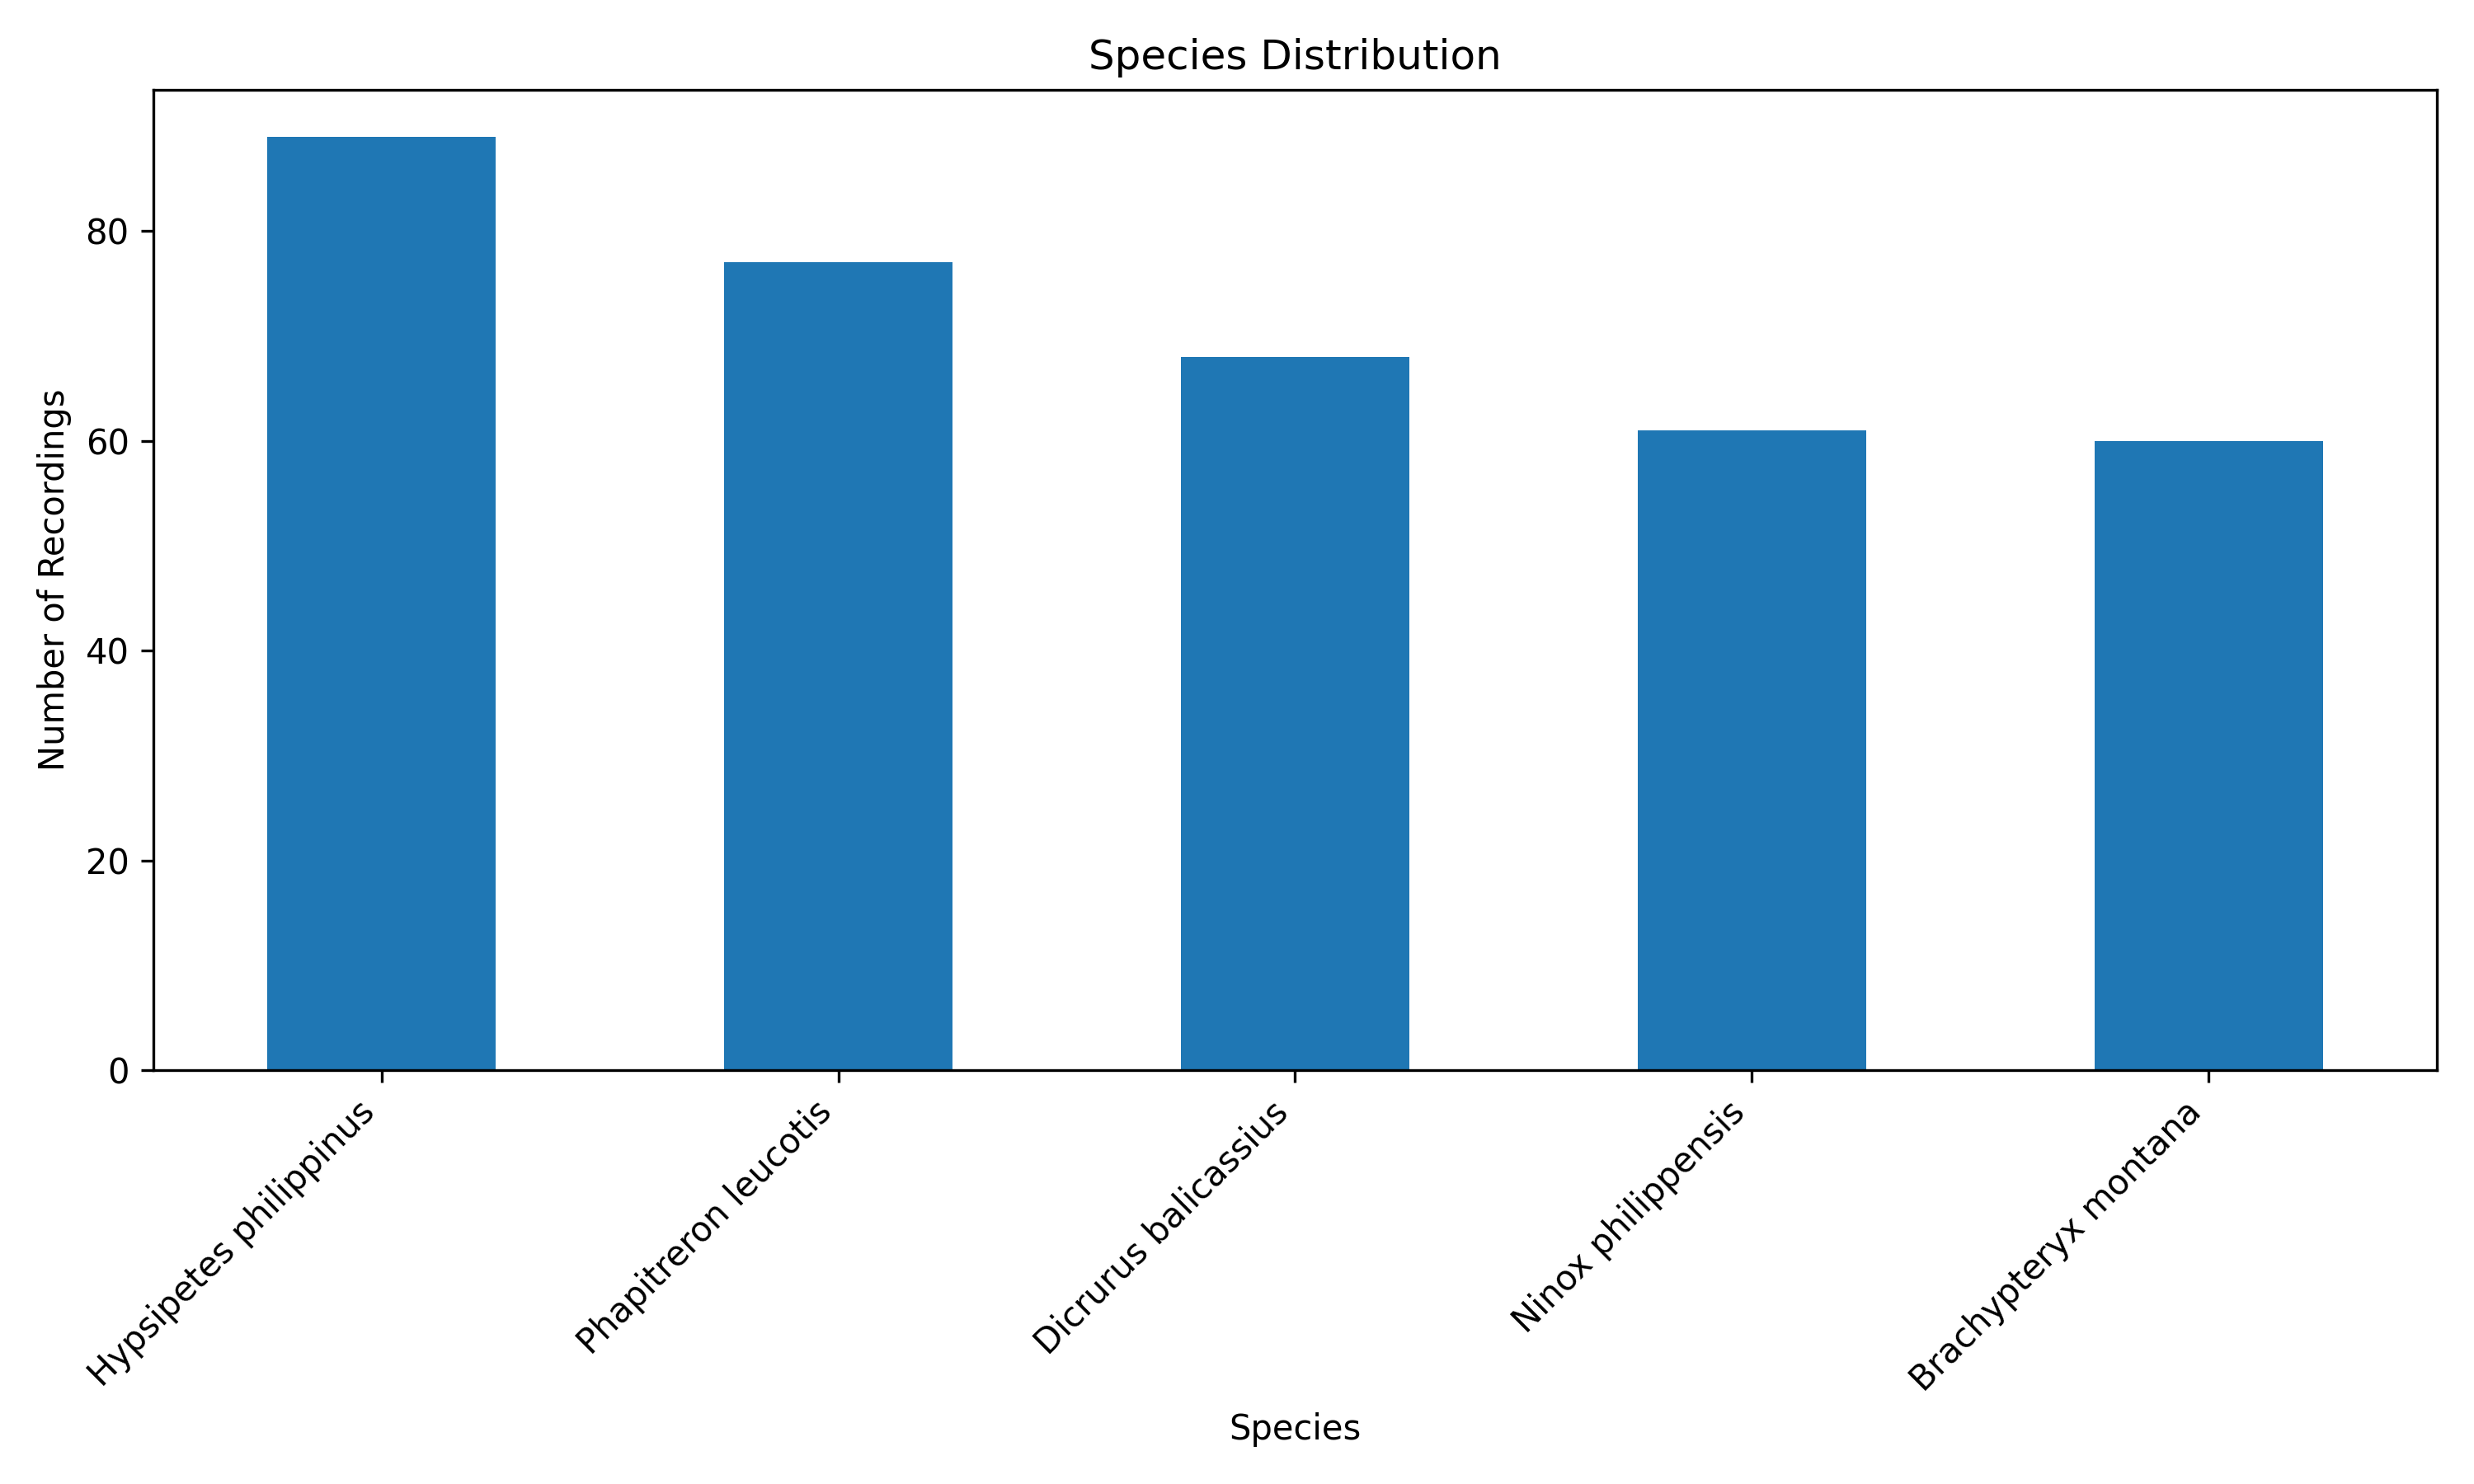

In [2]:
species_distribution_path = FIGURES_DIR / "species_distribution.png"

if species_distribution_path.exists():
    display(Image(filename=str(species_distribution_path)))
else:
    print("species_distribution.png not found.")

## Dataset Classes

The final classification task includes the following species:

1. Hypsipetes philippinus
2. Phapitreron leucotis
3. Dicrurus balicassius
4. Ninox philippensis
5. Brachypteryx montana

These species form a five-class classification problem.

In [3]:
metadata_files = list(DATA_DIR.rglob("*metadata*.csv")) + list(DATA_DIR.rglob("*.csv"))

metadata_files

[PosixPath('../data/processed/metadata/all_metadata.csv'),
 PosixPath('../data/raw/1990.csv'),
 PosixPath('../data/raw/1985.csv'),
 PosixPath('../data/raw/1991.csv'),
 PosixPath('../data/raw/1996.csv'),
 PosixPath('../data/raw/1997.csv'),
 PosixPath('../data/raw/1995.csv'),
 PosixPath('../data/raw/1994.csv'),
 PosixPath('../data/raw/2008.csv'),
 PosixPath('../data/raw/2020.csv'),
 PosixPath('../data/raw/2021.csv'),
 PosixPath('../data/raw/2009.csv'),
 PosixPath('../data/raw/2023.csv'),
 PosixPath('../data/raw/2022.csv'),
 PosixPath('../data/raw/2026.csv'),
 PosixPath('../data/raw/2025.csv'),
 PosixPath('../data/raw/2019.csv'),
 PosixPath('../data/raw/2018.csv'),
 PosixPath('../data/raw/2024.csv'),
 PosixPath('../data/raw/2001.csv'),
 PosixPath('../data/raw/2015.csv'),
 PosixPath('../data/raw/2014.csv'),
 PosixPath('../data/raw/2000.csv'),
 PosixPath('../data/raw/2016.csv'),
 PosixPath('../data/raw/2002.csv'),
 PosixPath('../data/raw/2003.csv'),
 PosixPath('../data/raw/2017.csv'),
 Posi

In [4]:
if metadata_files:
    df = pd.read_csv(metadata_files[0])
    display(df.head())
    display(df.info())
    display(df.describe(include="all"))
else:
    print("No metadata CSV found.")

,Common name,Scientific name,Subspecies,Recordist,Date,Time,Location,Country,Latitude,Longitude,Elevation,Songtype,Remarks,Back_latin,Catalogue number,License,metadata_file,species_folder
0,White-browed Shortwing,Brachypteryx montana,brunneiceps,Dindo Karl Mari Malonzo,2026-04-10,08:00,Mt. Mantalingahan mossy forest,Philippines,8.8114,117.6649,1700,call,NaN,Horornis flavolivaceus,1101514,https://creativecommons.org/licenses/by-nc-sa/...,Brachypteryx montana.csv,Brachypteryx montana
1,White-browed Shortwing,Brachypteryx montana,mindanensis,Pritam Baruah,2025-03-30,15:30,Mount Kitanglad Range Natural Park (near Mala...,Philippines,8.1373,124.9648,1700,song,NaN,NaN,987920,https://creativecommons.org/licenses/by-nc-sa/...,Brachypteryx montana.csv,Brachypteryx montana
2,White-browed Shortwing,Brachypteryx montana,undescribed,Hans Matheve,2024-03-22,?,"Mt Apo (Eden Nature Park), Davao del Sur, Dava...",Philippines,7.0301,125.3987,800,call,"ID not 100% sure, call was in reaction to play...",NaN,965139,https://creativecommons.org/licenses/by-nc-nd/...,Brachypteryx montana.csv,Brachypteryx montana
3,White-browed Shortwing,Brachypteryx montana,undescribed,Hans Matheve,2024-03-22,?,"Mt Apo (Eden Nature Park), Davao del Sur, Dava...",Philippines,7.0301,125.3987,800,song,"""Morris’s Shortwing""",NaN,965138,https://creativecommons.org/licenses/by-nc-nd/...,Brachypteryx montana.csv,Brachypteryx montana
4,White-browed Shortwing,Brachypteryx montana,undescribed,Hans Matheve,2024-03-22,?,"Mt Apo (Eden Nature Park), Davao del Sur, Dava...",Philippines,7.0301,125.3987,800,song,"""Morris’s Shortwing""",NaN,965137,https://creativecommons.org/licenses/by-nc-nd/...,Brachypteryx montana.csv,Brachypteryx montana


<class 'pandas.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Common name       355 non-null    str    
 1   Scientific name   355 non-null    str    
 2   Subspecies        244 non-null    str    
 3   Recordist         355 non-null    str    
 4   Date              355 non-null    str    
 5   Time              355 non-null    str    
 6   Location          355 non-null    str    
 7   Country           355 non-null    str    
 8   Latitude          308 non-null    float64
 9   Longitude         308 non-null    float64
 10  Elevation         355 non-null    str    
 11  Songtype          354 non-null    str    
 12  Remarks           108 non-null    str    
 13  Back_latin        43 non-null     str    
 14  Catalogue number  355 non-null    int64  
 15  License           355 non-null    str    
 16  metadata_file     355 non-null    str    
 17  species_

None

,Common name,Scientific name,Subspecies,Recordist,Date,Time,Location,Country,Latitude,Longitude,Elevation,Songtype,Remarks,Back_latin,Catalogue number,License,metadata_file,species_folder
count,355,355,244,355,355,355,355,355,308.000000,308.000000,355,354,108,43,3.550000e+02,355,355,355
unique,5,5,27,44,166,154,99,1,NaN,NaN,64,13,96,36,NaN,5,5,5
top,Philippine Bulbul,Hypsipetes philippinus,saturatior,Frank Lambert,2024-03-24,?:?,Negros; Mt. Canlaon,Philippines,NaN,NaN,750,song,feeding in a fruiting fig. Several birds present,Leonardina woodi,NaN,https://creativecommons.org/licenses/by-nc-sa/...,Hypsipetes philippinus.csv,Hypsipetes philippinus
freq,89,89,33,109,10,53,25,355,NaN,NaN,31,216,4,5,NaN,182,89,89
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.282565,123.305134,NaN,NaN,NaN,NaN,4.974337e+05,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.449819,2.008115,NaN,NaN,NaN,NaN,3.247197e+05,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.100900,117.664900,NaN,NaN,NaN,NaN,2.311600e+04,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.257000,121.350300,NaN,NaN,NaN,NaN,2.046355e+05,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.400000,123.178800,NaN,NaN,NaN,NaN,4.468510e+05,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.554700,125.289000,NaN,NaN,NaN,NaN,7.764900e+05,NaN,NaN,NaN
